In [39]:
#hide
#!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [40]:
#hide
from fastbook import *
from fastai.vision.widgets import *

Show Documenatation

In [41]:
show_doc(download_url)
# ?download_url
# ??download_url

<h4 id="download_url" class="doc_header"><code>download_url</code><a href="https://github.com/fastai/fastai/tree/master/fastai/data/external.py#L155" class="source_link" style="float:right">[source]</a></h4>

> <code>download_url</code>(**`url`**, **`dest`**, **`overwrite`**=*`False`*, **`pbar`**=*`None`*, **`show_progress`**=*`True`*, **`chunk_size`**=*`1048576`*, **`timeout`**=*`4`*, **`retries`**=*`5`*)

Download `url` to `dest` unless it exists and not `overwrite`

Download the images

In [42]:
key = '2167dda7082e41ff9be8b1f58335b64f'

results = search_images_bing(key, 'grizzly bear')
imgs = results.attrgot('contentUrl')

len(results)

150

In [43]:
imgs[1]

'http://2.bp.blogspot.com/-NjMTuklENdE/UHzVv_8dIxI/AAAAAAAAA-U/tNBsQDn8kFI/s1600/Grizzly+Bear+Pic.jpg'

In [44]:
?search_images_ddg

Signature: search_images_ddg(term, max_images=200)
Docstring: Search for `term` with DuckDuckGo and return a unique urls of about `max_images` images
File:      /opt/conda/lib/python3.6/site-packages/fastbook/__init__.py
Type:      function


Save the images

In [45]:
import os

# os.mkdir('images')

dest = 'images/grizzly.jpg'
# show_doc(download_url)

download_url(imgs[1], dest)

Show the image

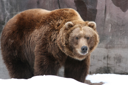

In [46]:
# show_doc(Image.open)
im = Image.open(dest)

im.to_thumb(128, 128)

Dope we just downloaded an image

In [47]:
bear_types = 'grizzly', 'black', 'teddy'
path = Path('bears')

Download the bears from their different types

In [48]:
# shutil.rmtree(path)

In [49]:
if not path.exists():
    path.mkdir()
    
for bear_type in bear_types:
    dest = (path/bear_type)
    dest.mkdir(exist_ok=True)

    results = search_images_bing(key, f'{bear_type} bear')
    download_images(dest, urls=results.attrgot('contentUrl'))

    # Convert all images to RGBA
    for image in os.listdir(dest):
        if image.endswith("png"):
            img = (dest/image)
            try:
                im = Image.open(img)
                im.convert("RGBA").save(img)
            except:
                print("Deleting image: ", img)
                os.remove(img)


Deleting image:  bears/black/00000053.png
Deleting image:  bears/black/00000100.png


In [51]:
show_doc(search_images_bing)

<h4 id="search_images_bing" class="doc_header"><code>search_images_bing</code><a href="https://github.com/fastai/course20/tree/master/fastbook.py#L46" class="source_link" style="float:right">[source]</a></h4>

> <code>search_images_bing</code>(**`key`**, **`term`**, **`min_sz`**=*`128`*, **`max_images`**=*`150`*)



List the images downloaded

In [52]:
fns = get_image_files(path)
fns

(#570) [Path('bears/grizzly/00000003.jpg'),Path('bears/grizzly/00000001.jpg'),Path('bears/grizzly/00000007.jpg'),Path('bears/grizzly/00000008.jpg'),Path('bears/grizzly/00000005.jpg'),Path('bears/grizzly/00000013.jpg'),Path('bears/grizzly/00000004.jpg'),Path('bears/grizzly/00000002.jpg'),Path('bears/grizzly/00000014.jpg'),Path('bears/grizzly/00000006.jpg')...]

Show images that failed to download 

In [53]:
failed = verify_images(fns)
failed

(#17) [Path('bears/grizzly/00000013.jpg'),Path('bears/grizzly/00000004.jpg'),Path('bears/grizzly/00000012.jpg'),Path('bears/grizzly/00000034.jpg'),Path('bears/grizzly/00000038.jpg'),Path('bears/grizzly/00000058.jpg'),Path('bears/grizzly/00000126.jpg'),Path('bears/grizzly/00000119.jpg'),Path('bears/black/00000094.jpg'),Path('bears/black/00000083.jpg')...]

Open python debugger

In [54]:
# %debug

Remove the images that cannot be downloaded

In [55]:
failed.map(Path.unlink)

# Reload the fns
fns = get_image_files(path)
fns

(#553) [Path('bears/grizzly/00000003.jpg'),Path('bears/grizzly/00000001.jpg'),Path('bears/grizzly/00000007.jpg'),Path('bears/grizzly/00000008.jpg'),Path('bears/grizzly/00000005.jpg'),Path('bears/grizzly/00000002.jpg'),Path('bears/grizzly/00000014.jpg'),Path('bears/grizzly/00000006.jpg'),Path('bears/grizzly/00000016.jpg'),Path('bears/grizzly/00000017.jpg')...]

Create data loaders 

In [56]:
show_doc(ImageClassifierCleaner)

<h2 id="ImageClassifierCleaner" class="doc_header"><code>class</code> <code>ImageClassifierCleaner</code><a href="https://github.com/fastai/fastai/tree/master/fastai/vision/widgets.py#L74" class="source_link" style="float:right">[source]</a></h2>

> <code>ImageClassifierCleaner</code>(**`learn`**, **`opts`**=*`()`*, **`height`**=*`128`*, **`width`**=*`256`*, **`max_n`**=*`30`*) :: `GetAttr`

A widget that provides an `ImagesCleaner` with a CNN `Learner`

In [57]:
dl_bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label, # `parent_label` -> Gets the name of the folder a file is in
    item_tfms=Resize(128)
)

dls = dl_bears.dataloaders(path)


Show the batch of images feed into the GPU

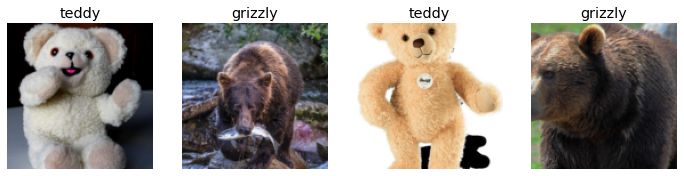

In [58]:
dls.valid.show_batch(max_n=4, nrows=1)

Resize the images

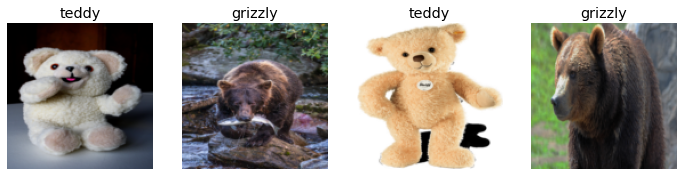

In [59]:
bears = dl_bears.new(item_tfms=Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

Resizing images with padding 

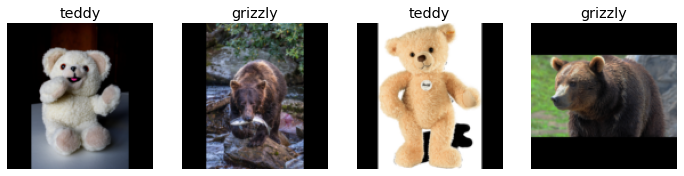

In [60]:
bears = dl_bears.new(item_tfms=Resize(128, ResizeMethod.Pad, pad_mode='zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)


Random cropping of the images

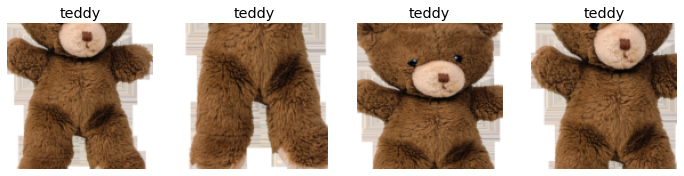

In [61]:
bears = dl_bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1, unique=True)

Data Augmentation

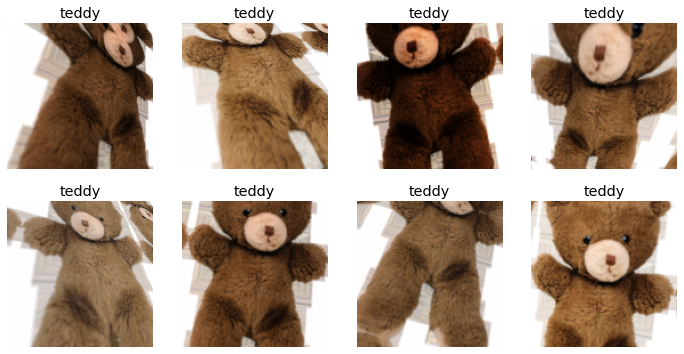

In [62]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=8, nrows=2, unique=True)

In [63]:
#?aug_transforms

Training your model & using it to clean your data

In [64]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())

dls = bears.dataloaders(path)

Fine tune model

In [65]:
learn = cnn_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

Create a confusion matrix

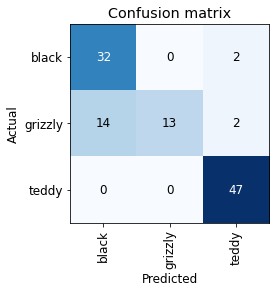

In [66]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

Plot the top losses (The loss is a number that is higher if the model is incorrect (especially if it's also confident of its incorrect answer), or if it's correct, but not confident of its correct answer)

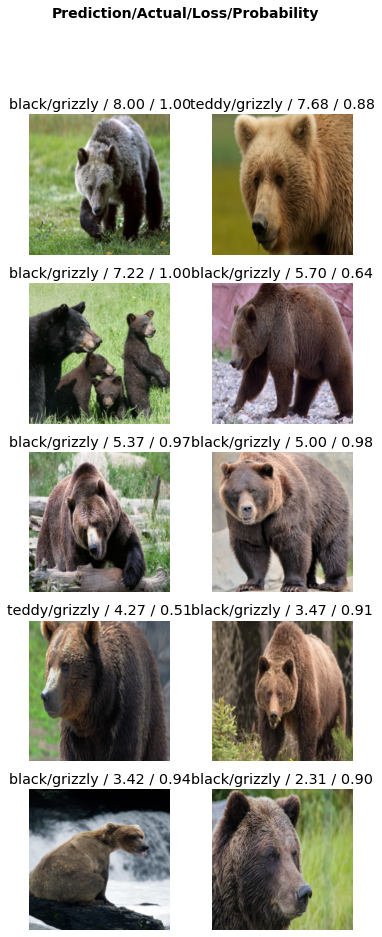

In [67]:
interp.plot_top_losses(10, nrows=5)

Simple model training for data cleanup

In [68]:
cleaner = ImageClassifierCleaner(learn)
cleaner

Delete the images marked by the cleaner for deletion

In [69]:
for idx in cleaner.delete():
    try:
        print('Deleting id', idx)
        cleaner.fns[idx].unlink()
    except:
        print('Failed to delete')

Move images marked for a different directory

In [70]:
for idx, directory in cleaner.change():
    try:
        img_path, ext = os.path.split(str(cleaner.fns[idx]))

        new_img = img_path + '_mv' + ext
        shutil.move(img, new_img)

        print('Moving id', new_img, directory)
        shutil.move(new_img, path/directory)
    except:
        print('Failed to move')

In [71]:
show_doc(cleaner.fns[0])

<h4 id="JPG" class="doc_header"><code>JPG</code><a href="" class="source_link" style="float:right">[source]</a></h4>

Path subclass for non-Windows systems.

On a POSIX system, instantiating a Path should return this object.

Plot again

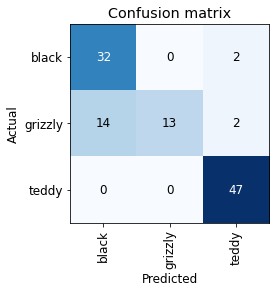

In [72]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

Export the model

In [93]:
learn.export()

Check if the model has been saved

In [94]:
path = Path()
path.ls(file_exts='.pkl')

(#1) [Path('export.pkl')]

Load a model

In [75]:
learn_inf = load_learner(path/'export.pkl')

Predict image from loaded model

In [76]:
learn_inf.predict('images/grizzly.jpg')
# 
learn_inf.dls.vocab

['black', 'grizzly', 'teddy']

NB -> Important side note: AI is dope

Create an app that uses the model we have just made

In [50]:
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value={}, description='Upload')

In [79]:
img = PILImage.create(btn_upload.data[-1])

In [81]:
# Display the image
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl:
    display(img.to_thumb(128, 127))
out_pl

Output()

Get the predictions 

In [84]:
pred, pred_idx, probs = learn_inf.predict(img)

In [89]:
# Show the predections
label = widgets.Label()
# label.value = f'Prediction: {pred}; Probability: {probs[pred_idx]}'
label.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
label

Label(value='Prediction: teddy; Probability: 1.0000')

Create the UI for our classifier

In [92]:
btn_run = widgets.Button(description="Classify")
btn_upload = widgets.FileUpload()
label_select = widgets.Label('Select your bear!')
label_pred = widgets.Label()
out_pl = widgets.Output()

def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    label_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run.on_click(on_click_classify)

VBox([label_select, btn_upload, btn_run, out_pl, label_pred])